In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv('Scores.csv', sep=';', decimal=',')
print(df.head())

   Unnamed: 0 student_id  gender parental.level.of.education   subject  score
0           1     id_001  female                 high school      math   23.0
1           2     id_001  female                 high school  language   40.0
2           3     id_002  female                 high school      math   68.0
3           4     id_002  female                 high school  language   80.5
4           5     id_003    male                 high school      math   82.0


In [3]:
missing_data = df.isnull().sum()
print("\n--- Missing Values ---")
print(missing_data[missing_data > 0])


--- Missing Values ---
Series([], dtype: int64)


In [14]:
print(df['student_id'].nunique())
print(df['gender'].unique())
print(df['subject'].unique())

486
<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['math', 'language']
Length: 2, dtype: str


In [5]:
gender_avg = df.groupby(['gender', 'subject'])['score'].mean().unstack()
print("\n moyennes par genre et subject: ")
print(gender_avg)


 moyennes par genre et subject: 
subject   language       math
gender                       
female   73.004082  63.857143
male     64.931535  68.946058


In [6]:
df['score_cat'] = pd.cut(df['score'],
                     bins=[0, 50, 75, 100],
                     labels= [ 'Low (<50)', 'Medium (50-75)', 'High (>75)'],
                     include_lowest=True,
                     ordered=True)
print("\nScore categories distribution:")
print(df['score_cat'].value_counts())


Score categories distribution:
score_cat
Medium (50-75)    542
High (>75)        307
Low (<50)         123
Name: count, dtype: int64


In [7]:
score_order = ['Low (<50)', 'Medium (50-75)', 'High (>75)']
df['score_cat'] = pd.Categorical(
    df['score_cat'], 
    categories=score_order, 
    ordered=True)

In [8]:
crosstab = pd.crosstab(
    [df['subject'], df['score_cat']],
    df['gender'],
    margins=True,
    margins_name='Total'

)
print("\n Effectifs absolus:")
print(crosstab)


 Effectifs absolus:
gender                   female  male  Total
subject  score_cat                          
language Low (<50)           15    35     50
         Medium (50-75)     123   147    270
         High (>75)         107    59    166
math     Low (<50)           45    28     73
         Medium (50-75)     146   126    272
         High (>75)          54    87    141
Total                       490   482    972


In [9]:
crosstab_pr = pd.crosstab(
    [df['subject'], df['score_cat']],
    df['gender'],
    normalize= 'columns'

) * 100
print("\n Effectifs absolus par pourcentage:")
print(crosstab_pr.round(1).astype(str) + '%')


 Effectifs absolus par pourcentage:
gender                  female   male
subject  score_cat                   
language Low (<50)        3.1%   7.3%
         Medium (50-75)  25.1%  30.5%
         High (>75)      21.8%  12.2%
math     Low (<50)        9.2%   5.8%
         Medium (50-75)  29.8%  26.1%
         High (>75)      11.0%  18.0%


In [10]:
crosstab_pr1 = pd.crosstab(
    [df['subject'], df['score_cat']],
    df['gender'],
    normalize= 'index'

) * 100
print("\n Effectifs absolus par pourcentage:")
print(crosstab_pr1.round(1).astype(str) + '%')


 Effectifs absolus par pourcentage:
gender                  female   male
subject  score_cat                   
language Low (<50)       30.0%  70.0%
         Medium (50-75)  45.6%  54.4%
         High (>75)      64.5%  35.5%
math     Low (<50)       61.6%  38.4%
         Medium (50-75)  53.7%  46.3%
         High (>75)      38.3%  61.7%


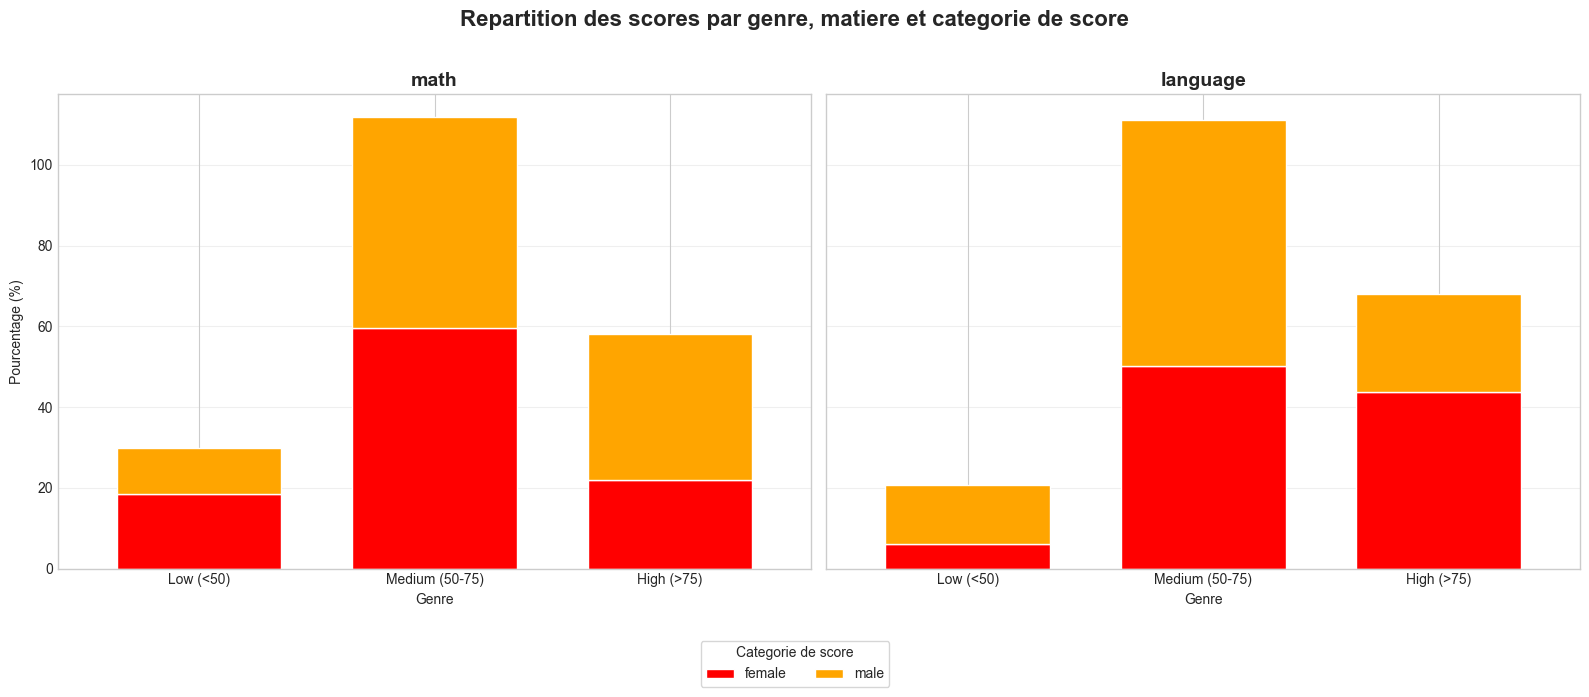

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Repartition des scores par genre, matiere et categorie de score',
             fontsize=16, fontweight='bold', y=1.02)
subjects = ['math', 'language']
colors = { 'Low (<50)': 'red', 'Medium (50-75)': 'orange', 'High (>75)': 'green' }
for ax, subject in zip(axes, subjects):
    subset = df[df['subject'] == subject]
    crosstab_pr2 = pd.crosstab(
        subset['score_cat'], 
        subset['gender'], 
        normalize='columns') *100
    crosstab_pr2.reindex(score_order).plot(
        kind='bar', 
        stacked=True, 
        color=[colors[cat] for cat in score_order], 
        ax=ax,
        edgecolor='white',
        width=0.7)
    ax.set_title(f'{subject}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Genre')
    ax.set_ylabel('Pourcentage (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.legend_.remove()
    ax.grid(axis='y', alpha=0.3)
    
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Categorie de score', loc='upper center', ncol=3, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

In [12]:

print("\n" + "═"*80)
print("📏 STATISTIQUES NUMÉRIQUES PAR GENRE ET MATIÈRE")
print("═"*80)

summary_stats = df.groupby(['subject', 'gender'])['score'].agg([
    ('count', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
    ('median', 'median'),
    ('min', 'min'),
    ('max', 'max')
]).round(2)

print(summary_stats)


════════════════════════════════════════════════════════════════════════════════
📏 STATISTIQUES NUMÉRIQUES PAR GENRE ET MATIÈRE
════════════════════════════════════════════════════════════════════════════════
                 count   mean    std  median   min    max
subject  gender                                          
language female    245  73.00  14.01    73.0  29.5  100.0
         male      241  64.93  13.75    65.5  19.5  100.0
math     female    245  63.86  15.26    64.0  23.0  100.0
         male      241  68.95  14.43    70.0  30.0  100.0


NameError: name 'df_filtered' is not defined

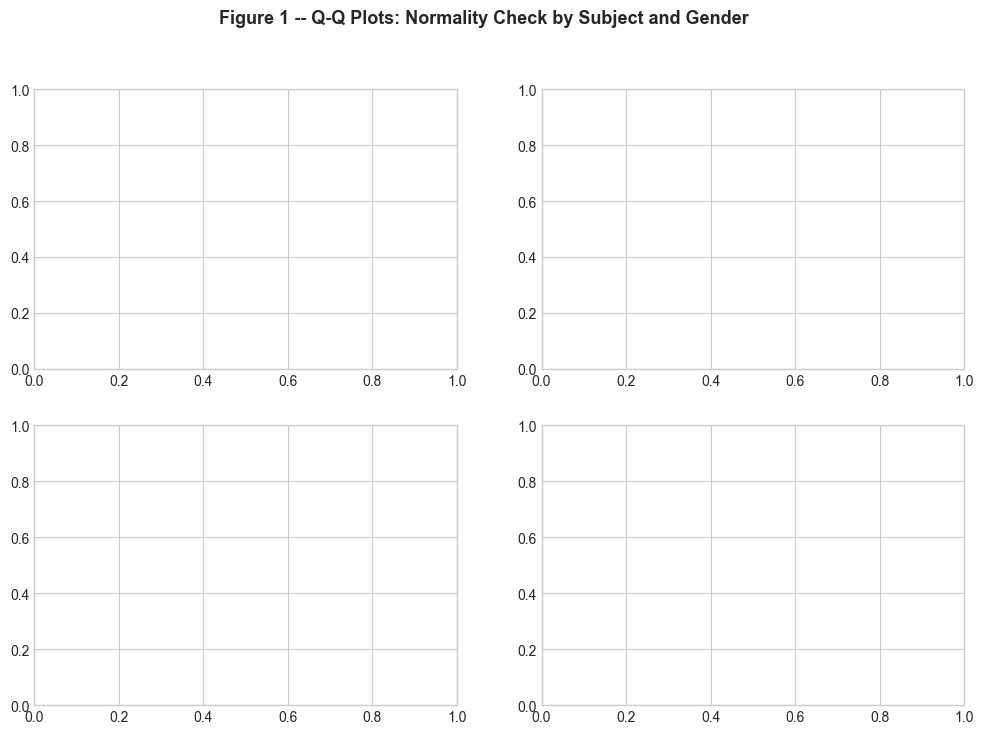

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Figure 1 -- Q-Q Plots: Normality Check by Subject and Gender',
             fontsize=13, fontweight='bold')
 
for idx, subject in enumerate(['language', 'math']):
    for jdx, gender in enumerate(['female', 'male']):
        ax = axes[idx, jdx]
        data = df_filtered[
            (df_filtered['subject'] == subject) &
            (df_filtered['gender'] == gender)
        ]['score']
        stats.probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{subject.title()} -- {gender.title()} (n={len(data)})",
                     fontsize=11)
        ax.get_lines()[0].set(color='steelblue', markersize=3, alpha=0.6)
        ax.get_lines()[1].set(color='crimson', linewidth=1.5)
 
plt.tight_layout()
plt.savefig('qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("  -> Figure 1 saved: qq_plots.png")
 

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('Scores.csv', sep=';', decimal=',')
df_filtered = df[df['subject'].isin(['math', 'language'])].copy()

# Create score categories
df_filtered['score_cat'] = pd.cut(
    df_filtered['score'],
    bins=[0, 50, 75, 100],
    labels=['Low (<50)', 'Medium (50-75)', 'High (>75)'],
    include_lowest=True
)

print("\n" + "═"*70)
print("🧪 HYPOTHESIS TESTS: Male vs Female")
print("═"*70)

for subject in ['language', 'math']:
    print(f"\n📘 {subject.upper()}")
    print("─"*60)
    
    # Get scores by gender
    male = df_filtered[(df_filtered['subject']==subject) & 
                       (df_filtered['gender']=='male')]['score']
    female = df_filtered[(df_filtered['subject']==subject) & 
                         (df_filtered['gender']=='female')]['score']
    
    # ─────────────────────────────────────────
    # 🔹 TEST 1: T-TEST (compare averages)
    # ─────────────────────────────────────────
    print(f"\n  📈 T-TEST: Comparing average scores")
    
    # Levene test for equal variances
    lev_stat, p_levene = stats.levene(male, female)
    equal_var = p_levene > 0.05
    variant   = "Student's t-test" if equal_var else "Welch's t-test"
 
    print(f"\n  🔬 Levene's Test (variance homogeneity):")
    print(f"     • F = {lev_stat:.4f} | p = {p_levene:.4f}")
    print(f"     • Equal variances: {'Yes' if equal_var else 'No'}")
    print(f"     -> Using: {variant}")
 
    
    # Format p-value properly
    t_stat, p_ttest = stats.ttest_ind(male, female, equal_var=equal_var)
    df_ttest = len(male) + len(female) - 2
 
    print(f"\n  📈 {variant}: Comparing mean scores")
    print(f"     H₀: μ_female = μ_male")
    print(f"     H₁: μ_female ≠ μ_male  (two-sided, α = 0.05)")
    print(f"     • ♀ Mean: {female.mean():.2f}  |  ♂ Mean: {male.mean():.2f}")
    print(f"     • Difference: {female.mean() - male.mean():+.2f} points")
    print(f"     • t({df_ttest}) = {t_stat:.3f}")
    p_disp = "p < 0.0001" if p_ttest < 0.0001 else f"p = {p_ttest:.4f}"
    print(f"     • {p_disp}")
 
    if p_ttest < 0.05:
        winner = "♀ females" if female.mean() > male.mean() else "♂ males"
        print(f"     ✅ SIGNIFICANT -- {winner} score significantly higher")
    else:
        print(f"     ❌ Not significant -- no evidence of mean difference")
    #cohen's d calculation
    n1, n2   = len(female), len(male)
    pooled   = np.sqrt(((n1-1)*female.var(ddof=1) + (n2-1)*male.var(ddof=1)) / (n1+n2-2))
    cohens_d = (female.mean() - male.mean()) / pooled
    magnitude = ("negligible" if abs(cohens_d) < 0.2 else
                 "small"      if abs(cohens_d) < 0.5 else
                 "medium"     if abs(cohens_d) < 0.8 else "large")
    print(f"     • Cohen's d = {cohens_d:.3f} -> {magnitude} effect size")
 
    # ─────────────────────────────────────────
    # 🔹 TEST 2: CHI² (compare category distribution)
    # ─────────────────────────────────────────
    print(f"\n  📦 CHI²: Comparing score category distribution")
    
    contingency = pd.crosstab(
        df_filtered[df_filtered['subject']==subject]['gender'],
        df_filtered[df_filtered['subject']==subject]['score_cat']
    )
    
    chi2, p_chi2, dof, _ = stats.chi2_contingency(contingency)
    
    print(f"     • Observed table:")
    print(f"       {contingency.to_string().replace(chr(10), chr(10)+'       ')}")
    print(f"     • χ²({dof}) = {chi2:.3f}")
    
    if p_chi2 < 0.0001:
        p_display = "p < 0.0001"
    else:
        p_display = f"p = {p_chi2:.4f}"
    print(f"     • {p_display}")
    
    if p_chi2 < 0.05:
        print(f"     ✅ SIGNIFICANT: Distribution differs by gender")
    else:
        print(f"     ❌ Not significant")
    
    print("\n" + "─"*60)


══════════════════════════════════════════════════════════════════════
🧪 HYPOTHESIS TESTS: Male vs Female
══════════════════════════════════════════════════════════════════════

📘 LANGUAGE
────────────────────────────────────────────────────────────

  📈 T-TEST: Comparing average scores

  🔬 Levene's Test (variance homogeneity):
     • F = 0.1596 | p = 0.6897
     • Equal variances: Yes
     -> Using: Student's t-test

  📈 Student's t-test: Comparing mean scores
     H₀: μ_female = μ_male
     H₁: μ_female ≠ μ_male  (two-sided, α = 0.05)
     • ♀ Mean: 73.00  |  ♂ Mean: 64.93
     • Difference: +8.07 points
     • t(484) = -6.409
     • p < 0.0001
     ✅ SIGNIFICANT -- ♀ females score significantly higher
     • Cohen's d = 0.581 -> medium effect size

  📦 CHI²: Comparing score category distribution
     • Observed table:
       score_cat  Low (<50)  Medium (50-75)  High (>75)
       gender                                          
       female            15             123         1

C:\Users\pc\AppData\Local\Temp\ipykernel_19976\3578457600.py:22: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.pointplot(
C:\Users\pc\AppData\Local\Temp\ipykernel_19976\3578457600.py:22: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


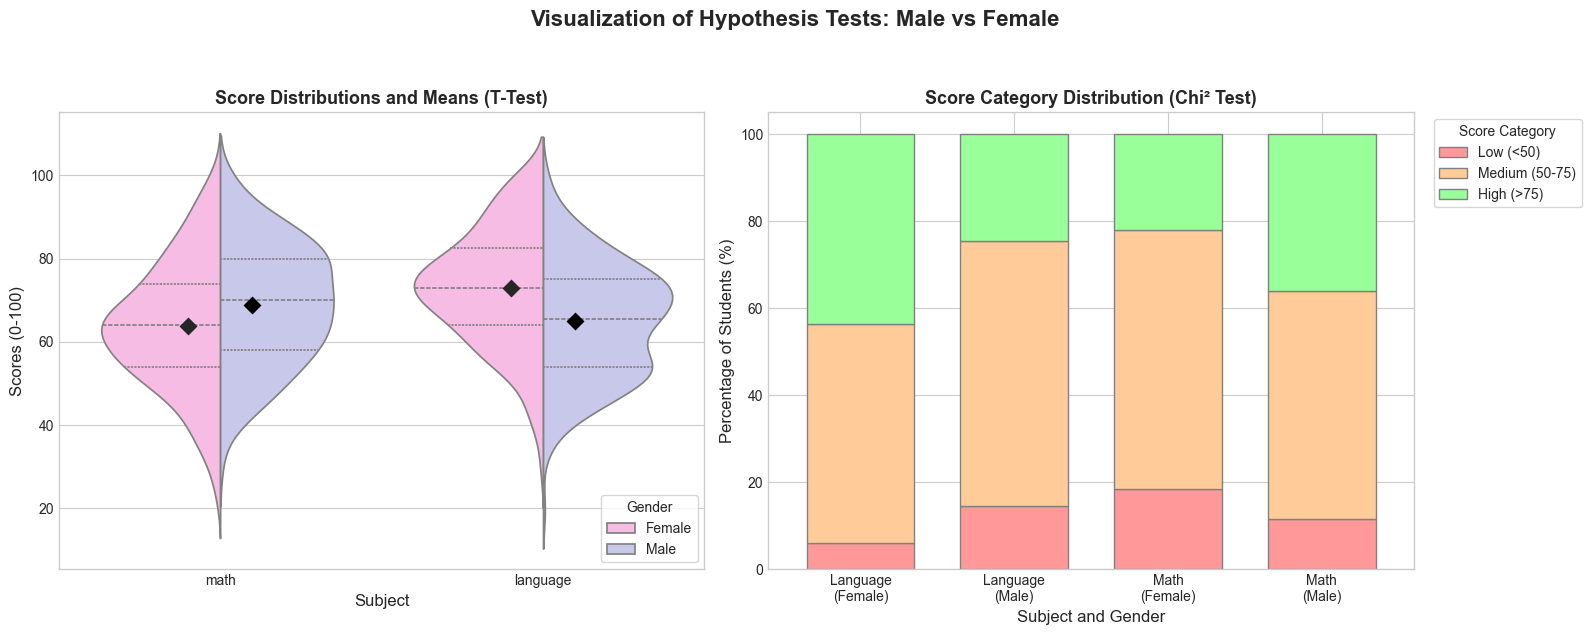

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for a professional look
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Visualization of Hypothesis Tests: Male vs Female', fontsize=16, fontweight='bold', y=1.05)

# ───────────────────────────────────────────────────────────────────
# Plot 1: Violin Plot with Means for T-Test
# ───────────────────────────────────────────────────────────────────
# The violin plot shows the distribution shapes, split by gender
sns.violinplot(
    data=df_filtered, x='subject', y='score', hue='gender',
    split=True, inner="quartile", palette={'female': '#ffb3e6', 'male': '#c2c2f0'}, 
    ax=axes[0]
)

# Overlay the absolute Mean marker (black diamond) to correspond with T-test averages
sns.pointplot(
    data=df_filtered, x='subject', y='score', hue='gender',
    estimator='mean', errorbar=None, dodge=0.2, join=False,
    color='black', markers='D', ax=axes[0]
)

axes[0].set_title('Score Distributions and Means (T-Test)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Subject', fontsize=12)
axes[0].set_ylabel('Scores (0-100)', fontsize=12)

# Clean up legend (remove duplicate labels generated by pointplot)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:2], ['Female', 'Male'], title='Gender', loc='lower right', frameon=True)


# ───────────────────────────────────────────────────────────────────
# Plot 2: 100% Stacked Bar Chart for Chi² (Category Distribution)
# ───────────────────────────────────────────────────────────────────
score_order = ['Low (<50)', 'Medium (50-75)', 'High (>75)']
colors_dict = {'Low (<50)': '#ff9999', 'Medium (50-75)': '#ffcc99', 'High (>75)': '#99ff99'}

# Prepare data: calculate percentages for each subject/gender combination
ct = pd.crosstab(
    [df_filtered['subject'], df_filtered['gender']], 
    df_filtered['score_cat'], 
    normalize='index'
) * 100

# Ensure columns are in the correct logical order
ct = ct[score_order]

# Plot stacked bar
ct.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[colors_dict[cat] for cat in score_order],
    edgecolor='gray', width=0.7
)

axes[1].set_title('Score Category Distribution (Chi² Test)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Subject and Gender', fontsize=12)
axes[1].set_ylabel('Percentage of Students (%)', fontsize=12)

# Format the x-axis ticks to look cleaner
x_labels = [f"{subj.title()}\n({gen.title()})" for subj, gen in ct.index]
axes[1].set_xticklabels(x_labels, rotation=0)

# Move legend outside the plot
axes[1].legend(title='Score Category', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()
